In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (recall_score, f1_score, roc_auc_score, 
                             precision_recall_curve, auc, confusion_matrix, 
                             classification_report, roc_curve)

# 1. Chargement des données de preprocessing

In [4]:
with open('../data/preprocessed_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

X_train: (19185, 46), X_test: (4797, 46)
y_train: (19185,), y_test: (4797,)


# 2. Entraînement du modèle de LogisticRegression

In [5]:
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)

lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_pred_proba_lr = lr.predict_proba(X_test)[:, 1]

# 3. Entraînement RandomForest

In [8]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]

# 4. Entraînement GradientBoosting

In [9]:
gb = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
y_pred_proba_gb = gb.predict_proba(X_test)[:, 1]

# 5. Fonction d'évaluation

In [10]:
def evaluate_model(y_true, y_pred, y_pred_proba, model_name):
    """Évalue un modèle avec recall, F1, ROC-AUC, PR-AUC"""
    
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_pred_proba)
    
    # PR-AUC
    precision, recall_curve_vals, thresholds = precision_recall_curve(y_true, y_pred_proba)
    pr_auc = auc(recall_curve_vals, precision)
    
    print(f"\n{model_name}:")
    print(f"  Recall:   {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  ROC-AUC:  {roc_auc:.4f}")
    print(f"  PR-AUC:   {pr_auc:.4f}")
    
    return {
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }

Évaluation des trois modèles

In [13]:
results_lr = evaluate_model(y_test, y_pred_lr, y_pred_proba_lr, "Logistic Regression")
results_rf = evaluate_model(y_test, y_pred_rf, y_pred_proba_rf, "Random Forest")
results_gb = evaluate_model(y_test, y_pred_gb, y_pred_proba_gb, "Gradient Boosting")


Logistic Regression:
  Recall:   0.9213
  F1-Score: 0.8169
  ROC-AUC:  0.9831
  PR-AUC:   0.9212

Random Forest:
  Recall:   0.8820
  F1-Score: 0.8895
  ROC-AUC:  0.9937
  PR-AUC:   0.9655

Gradient Boosting:
  Recall:   0.8778
  F1-Score: 0.9065
  ROC-AUC:  0.9960
  PR-AUC:   0.9787


# 6. Comparaison des modèles

In [17]:
comparison = pd.DataFrame({
    'Logistic Regression': results_lr,
    'Random Forest': results_rf,
    'Gradient Boosting': results_gb
}).T

comparison_metrics = comparison[['recall', 'f1', 'roc_auc', 'pr_auc']]

print("RÉSUMÉ COMPARATIF")
print(comparison_metrics.round(4))

# Meilleur modèle par métrique
print("\nMeilleur par métrique:")
for metric in ['recall', 'f1', 'roc_auc', 'pr_auc']:
    best = comparison_metrics[metric].idxmax()
    score = comparison_metrics[metric].max()
    print(f"  {metric.upper():8} → {best:25} ({score:.4f})")

RÉSUMÉ COMPARATIF
                       recall        f1   roc_auc    pr_auc
Logistic Regression  0.921348  0.816936  0.983081  0.921151
Random Forest        0.882022  0.889518  0.993728   0.96554
Gradient Boosting    0.877809  0.906454  0.996001  0.978719

Meilleur par métrique:
  RECALL   → Logistic Regression       (0.9213)
  F1       → Gradient Boosting         (0.9065)
  ROC_AUC  → Gradient Boosting         (0.9960)
  PR_AUC   → Gradient Boosting         (0.9787)


# 7. Visualisation ROC Curves

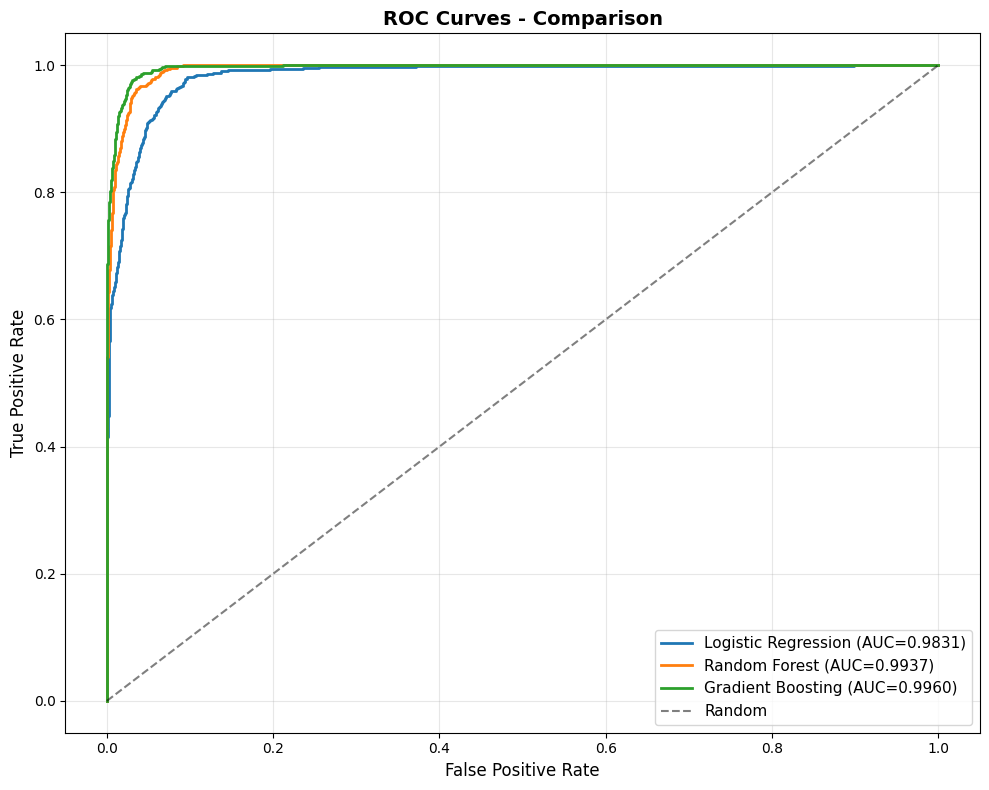

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# ROC curves
for name, pred_proba, results in [
    ('Logistic Regression', y_pred_proba_lr, results_lr),
    ('Random Forest', y_pred_proba_rf, results_rf),
    ('Gradient Boosting', y_pred_proba_gb, results_gb)
]:
    fpr, tpr, _ = roc_curve(y_test, pred_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={results["roc_auc"]:.4f})', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', label='Random', alpha=0.5)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 8. Visualisation - PR Curves

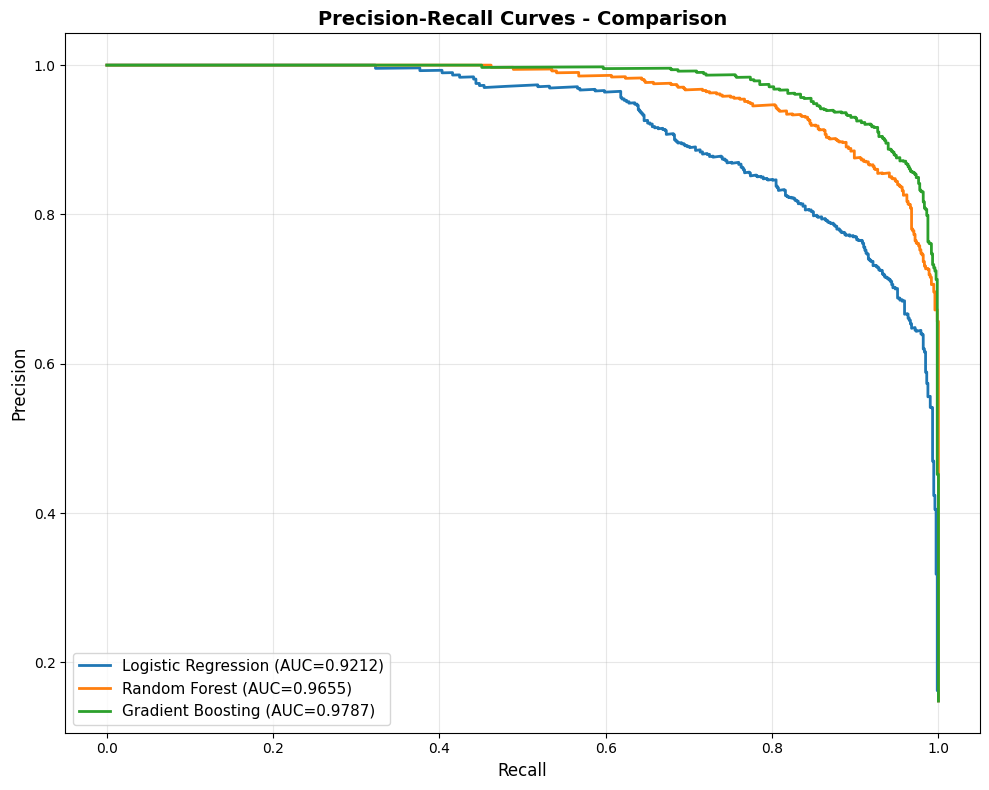

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

for name, pred_proba, results in [
    ('Logistic Regression', y_pred_proba_lr, results_lr),
    ('Random Forest', y_pred_proba_rf, results_rf),
    ('Gradient Boosting', y_pred_proba_gb, results_gb)
]:
    precision, recall_vals, _ = precision_recall_curve(y_test, pred_proba)
    pr_auc = auc(recall_vals, precision)
    ax.plot(recall_vals, precision, label=f'{name} (AUC={pr_auc:.4f})', linewidth=2)

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves - Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 9. Matrice de confusion

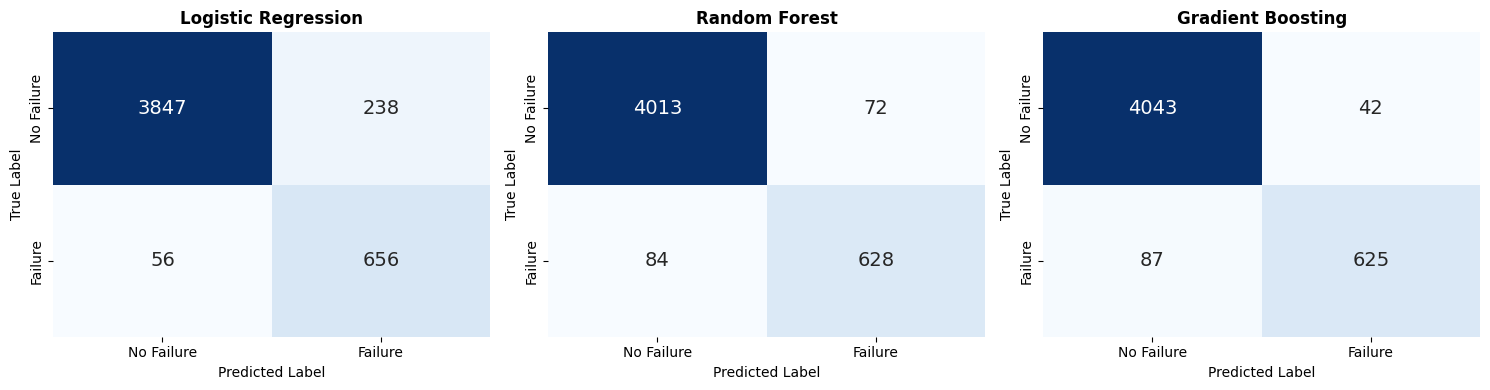

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (name, y_pred) in enumerate([
    ('Logistic Regression', y_pred_lr),
    ('Random Forest', y_pred_rf),
    ('Gradient Boosting', y_pred_gb)
]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], 
                cbar=False, annot_kws={'size': 14})
    axes[idx].set_title(f'{name}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_xticklabels(['No Failure', 'Failure'])
    axes[idx].set_yticklabels(['No Failure', 'Failure'])

plt.tight_layout()
plt.show()

# 10. Rapport de performance

In [25]:
best_model_name = comparison_metrics['recall'].idxmax()

if best_model_name == 'Logistic Regression':
    y_pred_best = y_pred_lr
elif best_model_name == 'Random Forest':
    y_pred_best = y_pred_rf
else:
    y_pred_best = y_pred_gb

print(f"MEILLEUR MODÈLE (par Recall): {best_model_name}")
print(classification_report(y_test, y_pred_best, 
                          target_names=['No Failure', 'Failure']))

MEILLEUR MODÈLE (par Recall): Logistic Regression
              precision    recall  f1-score   support

  No Failure       0.99      0.94      0.96      4085
     Failure       0.73      0.92      0.82       712

    accuracy                           0.94      4797
   macro avg       0.86      0.93      0.89      4797
weighted avg       0.95      0.94      0.94      4797



# 11. Sauvegarde des modèles

In [28]:
with open('../models/logistic_regression.pkl', 'wb') as f:
    pickle.dump(lr, f)

with open('../models/random_forest.pkl', 'wb') as f:
    pickle.dump(rf, f)

with open('../models/gradient_boosting.pkl', 'wb') as f:
    pickle.dump(gb, f)

# Sauvegarder les résultats
with open('../models/results.pkl', 'wb') as f:
    pickle.dump({
        'comparison': comparison_metrics,
        'results': {'lr': results_lr, 'rf': results_rf, 'gb': results_gb},
        'best_model': best_model_name
    }, f)

print("✅ Tous les modèles et résultats sauvegardés !")

✅ Tous les modèles et résultats sauvegardés !
